In [76]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)


1) FILTRO SOBEL

In [77]:
sobel_x = cv2.Sobel(img1, cv2.CV_64F, dx=1, dy=0, ksize=3)

sobel_y = cv2.Sobel(img1, cv2.CV_64F, dx=0, dy=1, ksize=3)

sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

sobel_x_disp = cv2.convertScaleAbs(sobel_x)
sobel_y_disp = cv2.convertScaleAbs(sobel_y)
sobel_mag_disp = cv2.convertScaleAbs(sobel_mag)

2) FILTRO ROBERTS

In [78]:
kernel_roberts_x = np.array([[1, 0],
                              [0, -1]], dtype=np.float64)

kernel_roberts_y = np.array([[0, 1],
                              [-1, 0]], dtype=np.float64)

img1_float = img1.astype(np.float64)

roberts_x = cv2.filter2D(img1_float, -1, kernel_roberts_x)
roberts_y = cv2.filter2D(img1_float, -1, kernel_roberts_y)

roberts_mag = np.sqrt(roberts_x**2 + roberts_y**2)

roberts_x_disp = cv2.convertScaleAbs(roberts_x)
roberts_y_disp = cv2.convertScaleAbs(roberts_y)
roberts_mag_disp = cv2.convertScaleAbs(roberts_mag)

3) VISUALIZAÇÃO DOS RESULTADOS

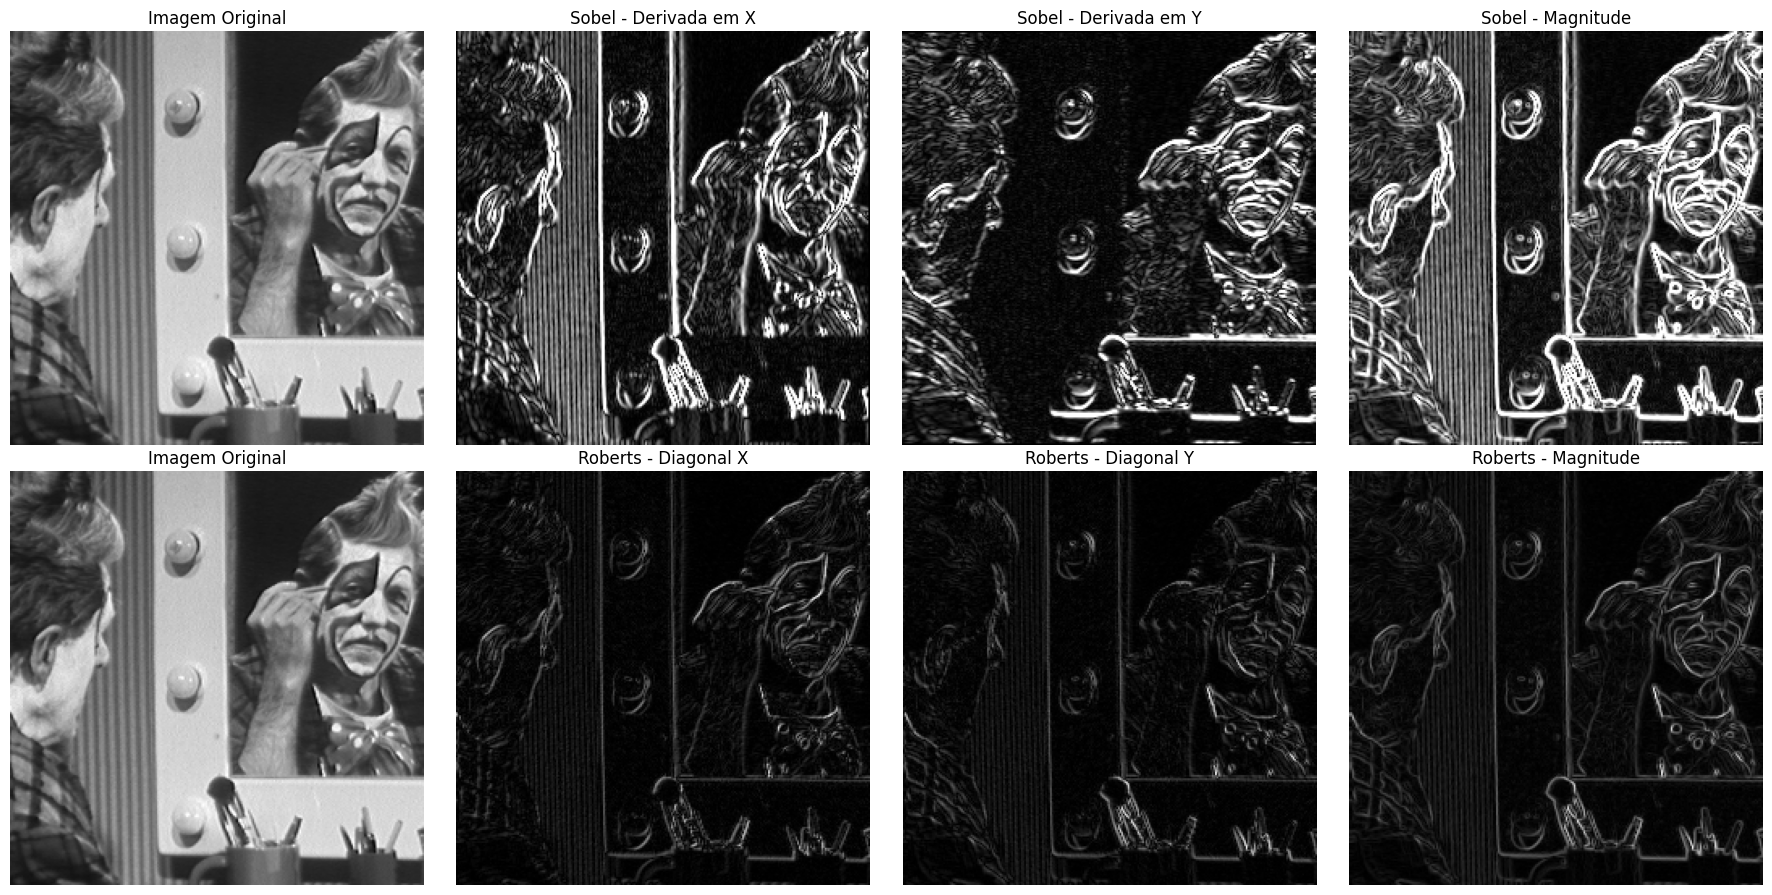

In [79]:
fig, axs = plt.subplots(2, 4, figsize=(18, 9))

axs[0, 0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title("Imagem Original")

axs[0, 1].imshow(sobel_x_disp, cmap='gray')
axs[0, 1].set_title("Sobel - Derivada em X")

axs[0, 2].imshow(sobel_y_disp, cmap='gray')
axs[0, 2].set_title("Sobel - Derivada em Y")

axs[0, 3].imshow(sobel_mag_disp, cmap='gray')
axs[0, 3].set_title("Sobel - Magnitude")

axs[1, 0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title("Imagem Original")

axs[1, 1].imshow(roberts_x_disp, cmap='gray')
axs[1, 1].set_title("Roberts - Diagonal X")

axs[1, 2].imshow(roberts_y_disp, cmap='gray')
axs[1, 2].set_title("Roberts - Diagonal Y")

axs[1, 3].imshow(roberts_mag_disp, cmap='gray')
axs[1, 3].set_title("Roberts - Magnitude")

for ax in axs.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

4. FILTRO LAPLACIANO

In [80]:
kernel_laplaciano = np.array([[ 0,  1,  0],
                               [ 1, -4,  1],
                               [ 0,  1,  0]], dtype=np.float64)

laplaciano = cv2.filter2D(img1_float, -1, kernel_laplaciano)

img_laplaciano_realce = img1_float - laplaciano
img_laplaciano_realce = np.clip(img_laplaciano_realce, 0, 255).astype(np.uint8)

laplaciano_disp = cv2.convertScaleAbs(laplaciano)

5. UNSHARP MASKING

In [81]:
blur = cv2.GaussianBlur(img1_float, (5, 5), sigmaX=1.0)
mask_unsharp = img1_float - blur

img_unsharp = img1_float + mask_unsharp 
img_unsharp = np.clip(img_unsharp, 0, 255).astype(np.uint8)

5. HIGHBOOST FILTERING (k > 1)

In [82]:
k_boost = 2.5  # k escolhido > 1
img_highboost = img1_float + k_boost * mask_unsharp
img_highboost = np.clip(img_highboost, 0, 255).astype(np.uint8)

6. K < 1 PARA ATENUAR (SUAVIZAR O REALCE)

In [83]:
k_atenua = 0.3  # k escolhido < 1
img_atenuada = img1_float + k_atenua * mask_unsharp
img_atenuada = np.clip(img_atenuada, 0, 255).astype(np.uint8)

VISUALIZAÇÃO DOS RESULTADOS

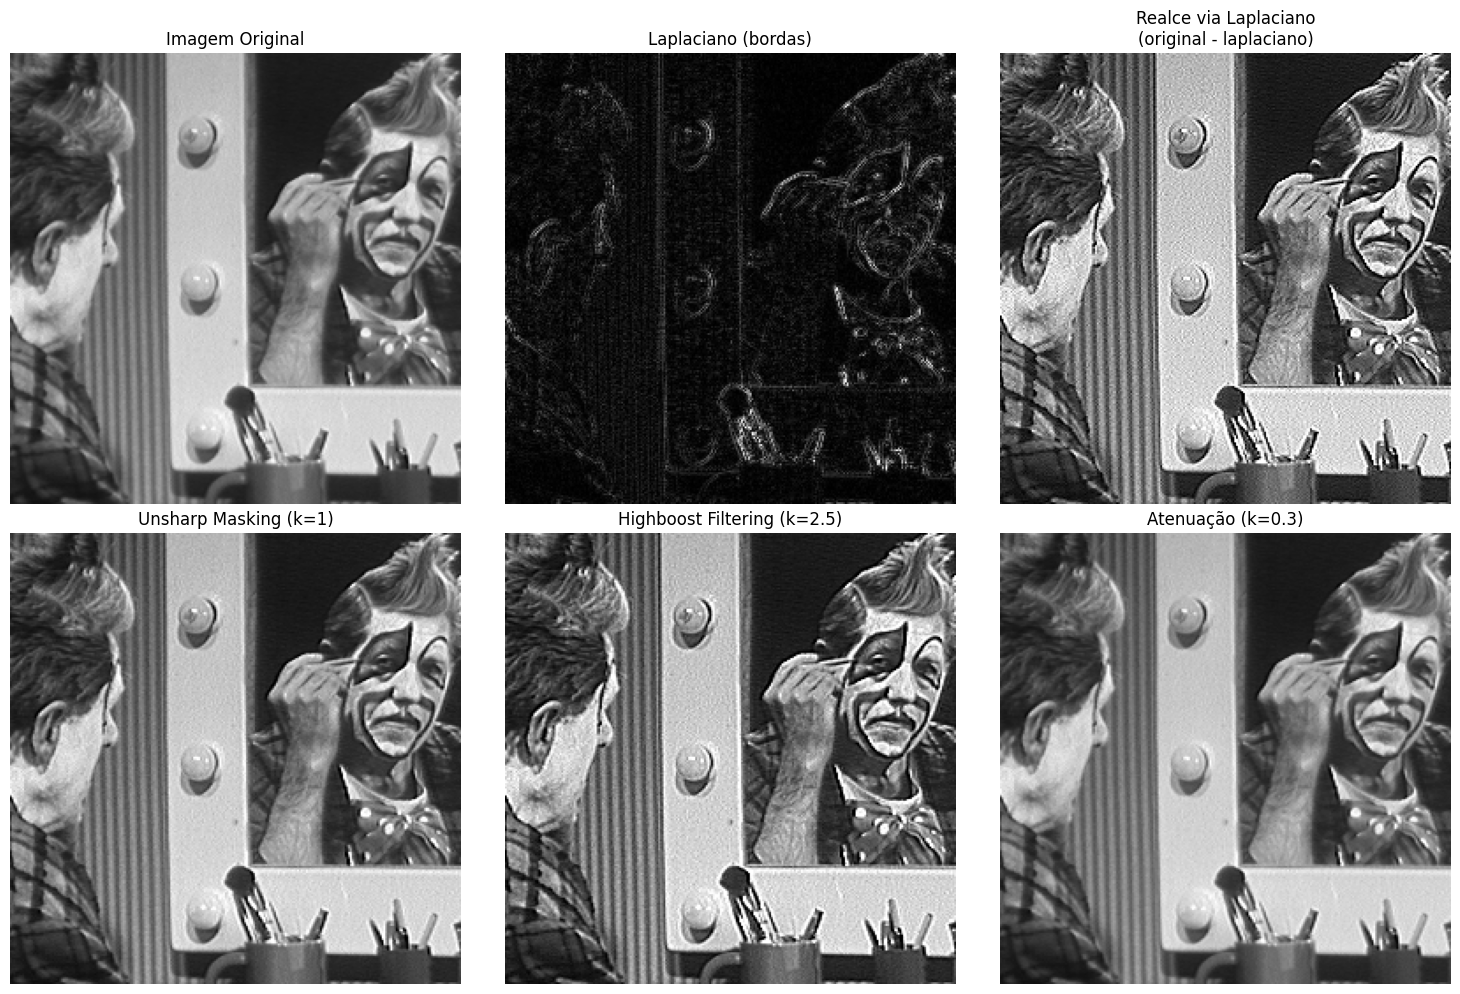

In [84]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

axs[0, 0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title("Imagem Original")

axs[0, 1].imshow(laplaciano_disp, cmap='gray')
axs[0, 1].set_title("Laplaciano (bordas)")

axs[0, 2].imshow(img_laplaciano_realce, cmap='gray', vmin=0, vmax=255)
axs[0, 2].set_title("Realce via Laplaciano\n(original - laplaciano)")

axs[1, 0].imshow(img_unsharp, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title("Unsharp Masking (k=1)")

axs[1, 1].imshow(img_highboost, cmap='gray', vmin=0, vmax=255)
axs[1, 1].set_title(f"Highboost Filtering (k={k_boost})")

axs[1, 2].imshow(img_atenuada, cmap='gray', vmin=0, vmax=255)
axs[1, 2].set_title(f"Atenuação (k={k_atenua})")

for ax in axs.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

Aplique o operador Sobel imagem original abaixo e obtenha as outras imagens conforme descrição. We can see that the intensity of many pixels on the surface is as high as along the actual edges. One reason is that the output of many edge pixels is greater than the maximum pixel value and therefore they are `cut off' at 255. To avoid this overflow we scale the range image by a factor 0.25 prior to the edge detection and then normalize the output, as can be seen in (c)

In [85]:
img1 = cv2.imread("ren1.png", cv2.IMREAD_GRAYSCALE)
img1_float = img1.astype(np.float64)

1. SOBEL NA IMAGEM ORIGINAL (SEM TRATAMENTO)

In [86]:
sobel_x_a = cv2.Sobel(img1_float, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y_a = cv2.Sobel(img1_float, cv2.CV_64F, dx=0, dy=1, ksize=3)
sobel_mag_a = np.sqrt(sobel_x_a**2 + sobel_y_a**2)

sobel_mag_a_disp = cv2.convertScaleAbs(sobel_mag_a)

print(f"Magnitude Sobel (original) - min: {sobel_mag_a.min():.1f}, max: {sobel_mag_a.max():.1f}")
print(f"Pixels que estouram 255: {np.sum(sobel_mag_a > 255)} de {sobel_mag_a.size}")

Magnitude Sobel (original) - min: 0.0, max: 1110.9
Pixels que estouram 255: 8607 de 65536


2. SOBEL COM PRÉ-ESCALONAMENTO (fator 0.25) + NORMALIZAÇÃO

In [87]:
fator_escala = 0.25
img1_scaled = img1_float * fator_escala

sobel_x_c = cv2.Sobel(img1_scaled, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y_c = cv2.Sobel(img1_scaled, cv2.CV_64F, dx=0, dy=1, ksize=3)
sobel_mag_c = np.sqrt(sobel_x_c**2 + sobel_y_c**2)

print(f"Magnitude Sobel (escalada 0.25) - min: {sobel_mag_c.min():.1f}, max: {sobel_mag_c.max():.1f}")

# Normalização min-max para [0, 255] (ao invés de convertScaleAbs, que só trunca)
sobel_mag_c_norm = cv2.normalize(sobel_mag_c, None, 0, 255, cv2.NORM_MINMAX)
sobel_mag_c_disp = sobel_mag_c_norm.astype(np.uint8)

Magnitude Sobel (escalada 0.25) - min: 0.0, max: 277.7


3. VISUALIZAÇÃO COMPARATIVA

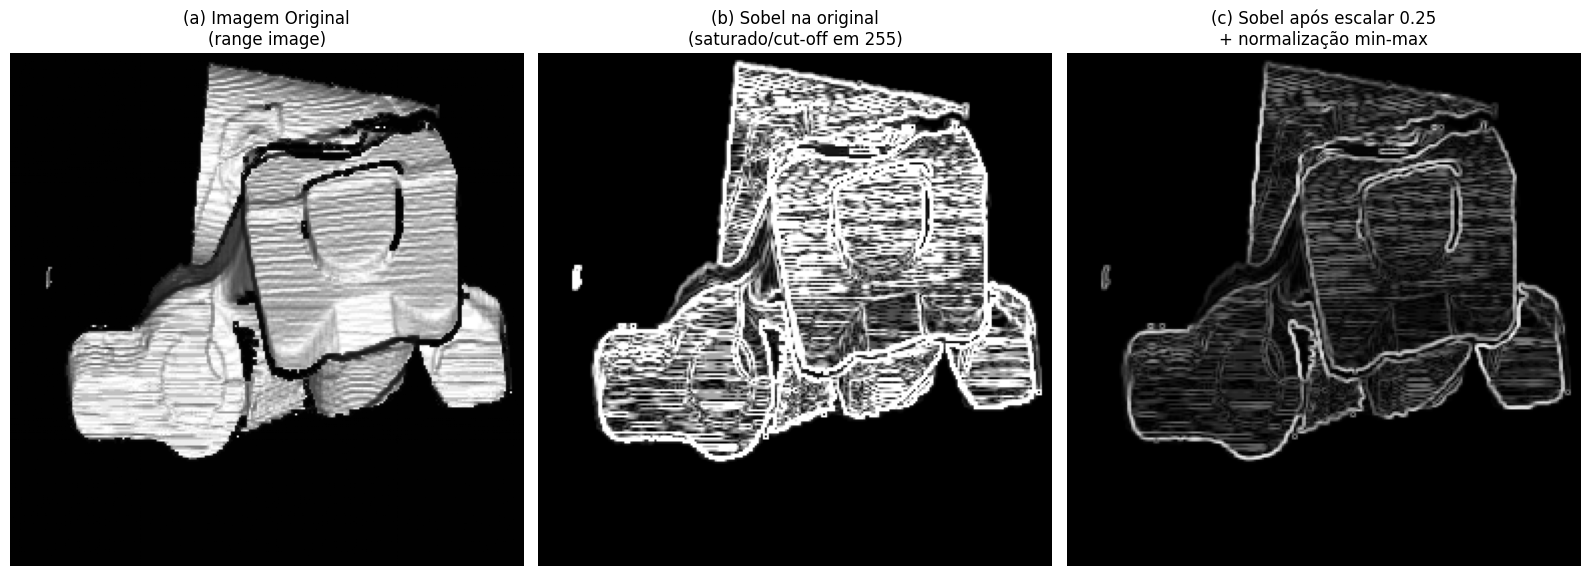

In [88]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

axs[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("(a) Imagem Original\n(range image)")

axs[1].imshow(sobel_mag_a_disp, cmap='gray', vmin=0, vmax=255)
axs[1].set_title("(b) Sobel na original\n(saturado/cut-off em 255)")

axs[2].imshow(sobel_mag_c_disp, cmap='gray', vmin=0, vmax=255)
axs[2].set_title("(c) Sobel após escalar 0.25\n+ normalização min-max")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

4. Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

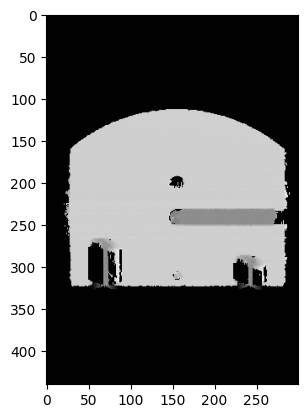

In [89]:
img1 = cv2.imread("ufo2.png", cv2.IMREAD_GRAYSCALE)
img1_float = img1.astype(np.float64)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255);

1. APLICAÇÃO DO OPERADOR SOBEL

In [90]:
sobel_x = cv2.Sobel(img1_float, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(img1_float, cv2.CV_64F, dx=0, dy=1, ksize=3)

sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

sobel_mag_disp = cv2.convertScaleAbs(sobel_mag)

2. LIMIARIZAÇÃO (THRESHOLDING) EM 150

In [91]:
limiar = 150
_, sobel_bin = cv2.threshold(sobel_mag_disp, limiar, 255, cv2.THRESH_BINARY)

VISUALIZAÇÃO DOS RESULTADOS

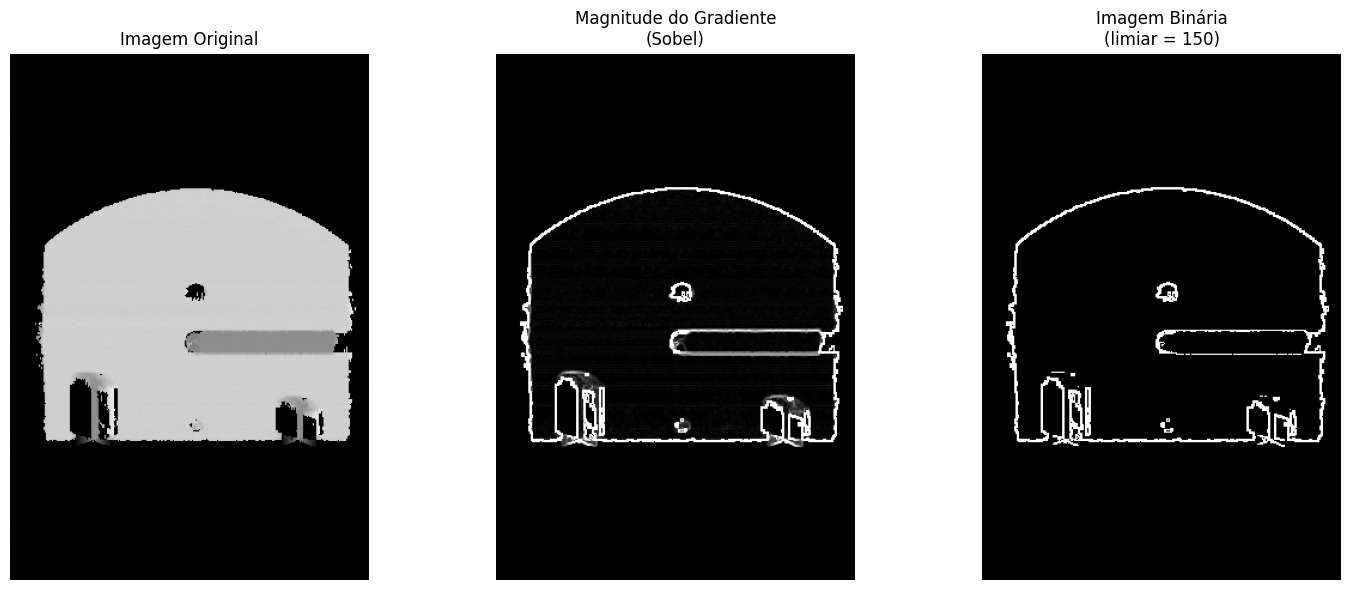

Total de pixels de borda (valor 255) após limiarização: 4245
Total de pixels de fundo (valor 0) após limiarização: 127755


In [92]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Imagem Original")

axs[1].imshow(sobel_mag_disp, cmap='gray', vmin=0, vmax=255)
axs[1].set_title("Magnitude do Gradiente\n(Sobel)")

axs[2].imshow(sobel_bin, cmap='gray', vmin=0, vmax=255)
axs[2].set_title(f"Imagem Binária\n(limiar = {limiar})")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Informação adicional
print(f"Total de pixels de borda (valor 255) após limiarização: {np.sum(sobel_bin == 255)}")
print(f"Total de pixels de fundo (valor 0) após limiarização: {np.sum(sobel_bin == 0)}")

5. Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

In [93]:
img1 = cv2.imread("ufo2noi2.png", cv2.IMREAD_GRAYSCALE)
img1_float = img1.astype(np.float64)

1. APLICAÇÃO DO OPERADOR SOBEL

In [94]:
sobel_x = cv2.Sobel(img1_float, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(img1_float, cv2.CV_64F, dx=0, dy=1, ksize=3)

sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag_disp = cv2.convertScaleAbs(sobel_mag)

2. LIMIARIZAÇÃO EM 150

In [95]:
limiar = 150
_, sobel_bin = cv2.threshold(sobel_mag_disp, limiar, 255, cv2.THRESH_BINARY)

VISUALIZAÇÃO

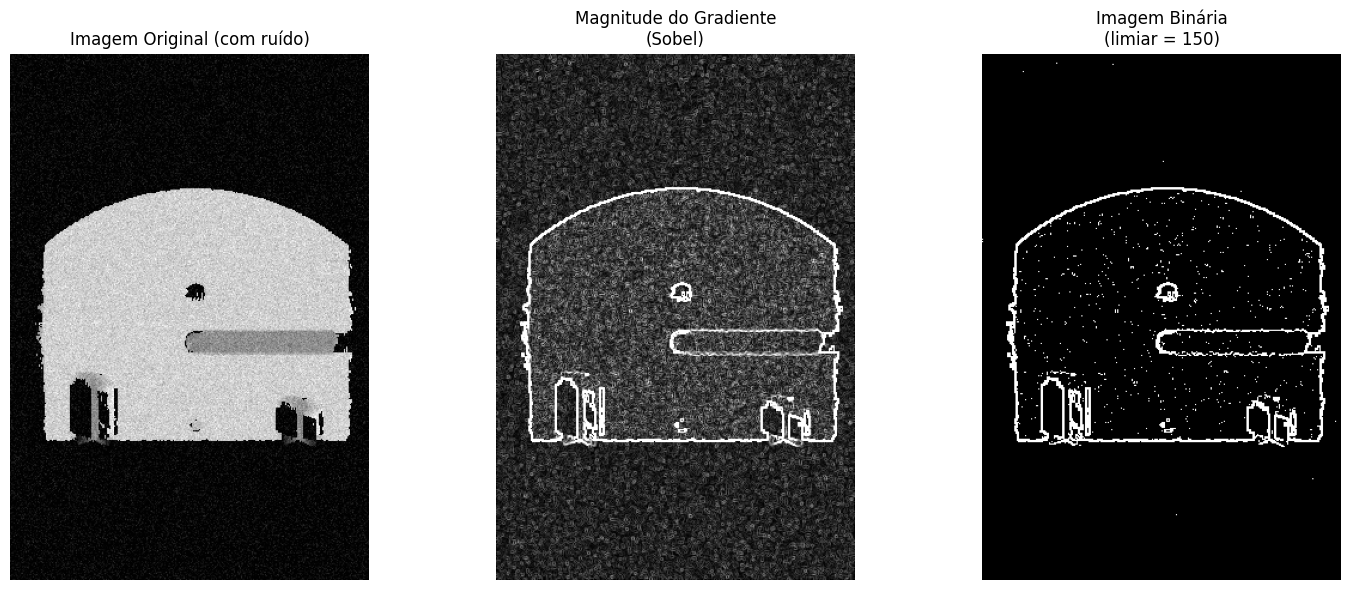

Total de pixels de borda (255): 5149
Percentual de pixels marcados como borda: 3.90%


In [96]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Imagem Original (com ruído)")

axs[1].imshow(sobel_mag_disp, cmap='gray', vmin=0, vmax=255)
axs[1].set_title("Magnitude do Gradiente\n(Sobel)")

axs[2].imshow(sobel_bin, cmap='gray', vmin=0, vmax=255)
axs[2].set_title(f"Imagem Binária\n(limiar = {limiar})")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Total de pixels de borda (255): {np.sum(sobel_bin == 255)}")
print(f"Percentual de pixels marcados como borda: {100*np.sum(sobel_bin==255)/sobel_bin.size:.2f}%")